In [1]:
import os

# Standard library
import hashlib
import random
import sys
from glob import glob

# Data science / visualization
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import numpy as np
import pandas as pd

# Image utilities

from PIL import Image
import cv2

# Progress bar
from tqdm import tqdm

# Machine learning / keras
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
from tensorflow.keras import Input
from tensorflow.keras import layers, models, Sequential, optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
from keras_preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D, MaxPool2D, UpSampling2D

# Statistics & metrics
from scipy.stats import gamma, beta
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Notebook plotting defaults
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

# Project utilities (if any local helper functions exist in utils.py)
import utils

# Note: keep imports idempotent and avoid re-importing same modules multiple times.


In [2]:
def load_image_files(root_path):
    """
    Load all image file names from the given directory.

    Args:
        root_path (str): The root directory containing image files.

    Returns:
        list: A list of image file paths found in the directory.
    """
    image_file_paths = []
    for file_name in os.listdir(root_path):
        file_path = os.path.join(root_path, file_name)
        if file_path.endswith('.png'):
            image_file_paths.append(file_path)
    return image_file_paths


def load_images(image_files, scale=True):
    """
    Load and preprocess images from a list of file paths.

    Args:
        image_files (list): A list of file paths to image files.

    Returns:
        np.array: An array of preprocessed images (grayscale, normalized).
    """
    images = []
    for file_path in image_files:
        img = image.load_img(file_path, target_size=(64, 64), color_mode='grayscale')
        img = image.img_to_array(img)
        if scale == True:
            img = img / 255.0  # Normalize pixel values to [0, 1]
        images.append(img)
    return np.array(images)


def load_data(root_path, scale = True):
    """
    Load and preprocess image data from a given directory.

    Args:
        root_path (str): The root directory containing image files.

    Returns:
        np.array: Flattened preprocessed image data.
    """
    image_files = load_image_files(root_path)
    images = load_images(image_files, scale)
    data = images.reshape(-1, 64)
    return data


def plot_images(images, titles=None, cols=5, cmap='gray'):
    """
    Display multiple images in a grid layout.

    Args:
        images (list or np.array): List or array of images to plot.
        titles (list, optional): Titles for each image. Defaults to None.
        cols (int, optional): Number of columns in the grid. Defaults to 5.
        cmap (str, optional): Colormap for displaying images. Defaults to 'gray'.
    """
    rows = len(images) // cols + int(len(images) % cols > 0)
    plt.figure(figsize=(15, 3 * rows))
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img.squeeze(), cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [3]:
path_train = 'MCMD-2025/train/Normal'
data_train = load_data(path_train)

path_val = 'MCMD-2025/val/Normal'
data_val = load_data(path_val)

In [4]:
def autoencoder_model(input_dims):
    # Define a simple autoencoder model using Keras Functional API
    
    # Input layer: expects a vector of size input_dims
    inputLayer = Input(shape=(input_dims,))

    # Encoder: compress input into 1-dimensional latent space
    h = Dense(1, activation="relu")(inputLayer)
        
    # Decoder: reconstruct the input from the latent representation
    h = Dense(input_dims, activation=None)(h)

    # Return the full autoencoder model
    return Model(inputs=inputLayer, outputs=h)


# Create the autoencoder model with input size 64
model = autoencoder_model((64))

# Display model architecture summary
model.summary()

# Compile the model with mean squared error loss and Adam optimizer
model.compile(
        loss='mean_squared_error',
        optimizer=Adam(learning_rate=1e-3))

# Train the autoencoder using training data
# The model tries to reconstruct its own input
history = model.fit(
    data_train, data_train,                  # input and target are the same
    validation_data=(data_val, data_val),    # use validation set for monitoring
    epochs=5,                                # number of training epochs
    batch_size=64,                           # number of samples per gradient update
    shuffle=True)                            # shuffle data before each epoch


2025-10-30 15:48:12.272677: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-10-30 15:48:12.272830: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-10-30 15:48:12.272837: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-10-30 15:48:12.273095: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-30 15:48:12.273107: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


2025-10-30 15:48:12.721505: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0547 - val_loss: 0.0011
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 9.3059e-04 - val_loss: 9.8344e-04
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 8.8038e-04 - val_loss: 9.3148e-04
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 8.3399e-04 - val_loss: 8.6955e-04
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 7.9054e-04 - val_loss: 8.2446e-04


In [5]:
model.save("autoendcoder.h5")

In [6]:
def plot_history(history):
    """Plot training and validation loss over epochs.

    Args:
        history (History object): The history object returned by model.fit().
    """
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss Over Epochs', fontsize=18)
    plt.xlabel('Epochs', fontsize=18)
    plt.ylabel('Loss', fontsize=18)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(fontsize=18)
    plt.show()

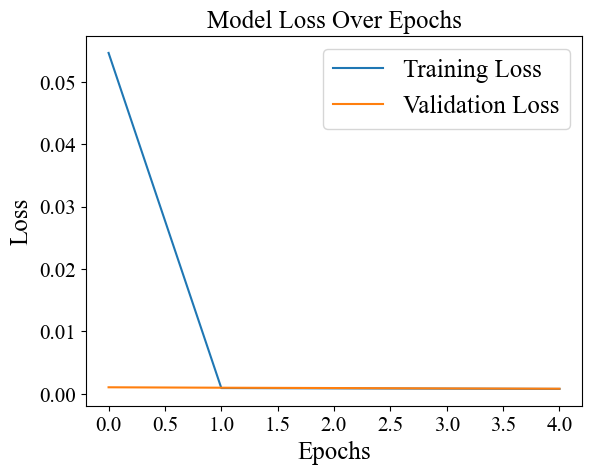

In [7]:
plot_history(history)

In [8]:
def distribution(representation_data, autoencoder_model):
    """Compute reconstruction errors for a dataset using the provided autoencoder.

    This function iterates over the dataset in batches, reconstructs each batch
    using the autoencoder, and computes the mean squared error per sample.

    Args:
        representation_data (np.ndarray): Input data shaped (N, features).
        autoencoder_model (tf.keras.Model): Trained autoencoder model.

    Returns:
        np.ndarray: 1D array of per-sample MSE values with shape (N,).
    """
    errors_list = []
    batch_size = 64
    # iterate in batches to avoid large memory usage
    for start_idx in tqdm(range(0, representation_data.shape[0], batch_size)):
        batch = representation_data[start_idx:start_idx + batch_size, :]
        reconstructed_batch = autoencoder_model.predict(batch, verbose=0)
        # per-sample MSE for the batch
        # batch_mse = np.mean(np.square(batch - reconstructed_batch), axis=1)
        batch_mse = np.mean(np.mean(np.square(batch - reconstructed_batch), axis=1))
        errors_list.append(batch_mse)
    return np.array(errors_list)


In [9]:
# Load abnormal / test datasets (each returns features shaped (N,64))
data_bearing_failure = load_data('MCMD-2025/train/Bearing_failure')
data_phase_shift = load_data('MCMD-2025/train/Phase_shift')
data_phase_loss = load_data('MCMD-2025/train/Phase_loss')

# Compute per-sample MSE reconstruction error arrays using the autoencoder model
# (keeps the original code's expectation of 1D error arrays for downstream plotting)
distribution_normal = distribution(data_train, model)
distribution_bearing_failure = distribution(data_bearing_failure, model)
distribution_phase_shift = distribution(data_phase_shift, model)
distribution_phase_loss = distribution(data_phase_loss, model)


100%|██████████| 1200/1200 [00:40<00:00, 29.47it/s]


In [10]:
def plot_results(errors_normal, errors_phase_imbalance, errors_phase_loss, errors_bearing_fault, p=0.01, bin_width=0.00005, x_min=0, x_max=0.020):
    """Plot histograms of reconstruction errors for normal vs several anomaly types.

    This function fits a Gamma distribution to the normal reconstruction errors to
    estimate a cutoff threshold (quantile 1-p). It then plots overlaid histograms
    for each class and marks the cutoff.

    Args:
        errors_normal (array-like): Per-sample reconstruction errors for normal data.
        errors_phase_imbalance (array-like): Reconstruction errors for phase imbalance.
        errors_phase_loss (array-like): Reconstruction errors for phase loss.
        errors_bearing_fault (array-like): Reconstruction errors for bearing fault.
        p (float): Tail probability used to compute cutoff (default 0.01 -> 99th percentile).
        bin_width (float): Histogram bin width.
        x_min (float): x-axis minimum value for plotting.
        x_max (float): x-axis maximum value for plotting.

    Returns:
        float: cutoff value computed from fitted Gamma distribution on the normal errors.
    """
    # Normalize inputs to 1D numpy arrays
    classes = {
        'Normal': np.asarray(errors_normal).ravel(),
        'Phase shift': np.asarray(errors_phase_imbalance).ravel(),
        'Phase loss': np.asarray(errors_phase_loss).ravel(),
        'Bearing failure': np.asarray(errors_bearing_fault).ravel(),
    }

    # Remove empty classes and warn
    classes = {k: v for k, v in classes.items() if v.size > 0}
    if 'Normal' not in classes or classes['Normal'].size == 0:
        raise ValueError('Normal class errors are required and must be non-empty to compute cutoff.')

    # Fit Gamma distribution to normal errors (force loc=0 for stability)
    gamma_params = gamma.fit(classes['Normal'], floc=0)
    shape_param = gamma_params[0]
    scale_param = gamma_params[2]
    cutoff = gamma.ppf(1 - p, shape_param, scale=scale_param)

    # Prepare combined array for plotting order and labels
    combined_errors = np.concatenate(list(classes.values()), axis=0)
    # create label array matching combined_errors
    labels = []
    for name, arr in classes.items():
        labels.extend([name] * arr.size)
    labels = np.array(labels)

    # Create bins across the relevant range
    min_edge = max(0.0, np.min(combined_errors))
    max_edge = max(np.max(combined_errors), x_max)
    bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    # Plot
    plt.figure(figsize=(12, 5))
    palette = {
        'Normal': '#2CBDFE',
        'Phase shift': '#47DBCD',
        'Phase loss': 'navy',
        'Bearing failure': '#9D2EC5'
    }

    for name, arr in classes.items():
        plt.hist(arr, bins=bins, color=palette.get(name, '#888888'), alpha=0.65,
                 label=f'{name} (n={len(arr)})', edgecolor='white')

    # Mark the cutoff line
    plt.axvline(cutoff, linestyle='--', linewidth=2, color='#FF2768',
                label=f'Cutoff (1-p={1-p:.2f}): {cutoff:.5f}', alpha=0.9)

    plt.title('Reconstruction Error Distribution (Normal vs Anomalies)', fontsize=20)
    plt.xlabel('Reconstruction Error (MSE)', fontsize=20)
    plt.ylabel('Probability density', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.grid(alpha=0.2)
    plt.show()

    return cutoff


def confusion_m(errors_normal, errors_abnormal, threshold):
    """Compute confusion matrix and classification metrics given a threshold.

    Args:
        errors_normal (array-like): Reconstruction errors for normal samples.
        errors_abnormal (array-like): Reconstruction errors for abnormal samples.
        threshold (float): Threshold above which a sample is classified as abnormal.

    Returns:
        dict: A dictionary with keys: 'confusion_matrix', 'accuracy', 'precision', 'recall', 'f1'
    """
    y_true = np.array([0] * len(errors_normal) + [1] * len(errors_abnormal))
    y_pred = np.array([0 if e < threshold else 1 for e in np.concatenate((errors_normal, errors_abnormal))])

    # Compute confusion matrix and metrics (safe handling when some classes might be missing)
    xticklabels=['Normal', 'Abnormal']
    yticklabels=['Normal', 'Abnormal']
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(3, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=xticklabels, yticklabels=yticklabels, 
                annot_kws={"size": 10})
    plt.ylabel('True label', fontsize=10)
    plt.xlabel('Predicted label', fontsize=10)
    plt.title('Confusion Matrix', fontsize=10)
    plt.xticks(fontsize=10, rotation=45)
    plt.yticks(fontsize=10, rotation=0)
    plt.show()

    # Avoid division by zero in precision/recall when there are no positive predictions
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # # Display confusion matrix as counts and normalized percentages
    # fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    #             xticklabels=['Pred Normal', 'Pred Abnormal'], yticklabels=['True Normal', 'True Abnormal'])
    # axes[0].set_title('Confusion Matrix (counts)')

    # cm_percent = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
    # sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
    #             xticklabels=['Pred Normal', 'Pred Abnormal'], yticklabels=['True Normal', 'True Abnormal'])
    # axes[1].set_title('Confusion Matrix (by true-row %)')

    # plt.tight_layout()
    # plt.show()

    metrics = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }
    # Print summary metrics
    print('Accuracy: {:.4f}'.format(accuracy))
    print('Precision: {:.4f}'.format(precision))
    print('Recall: {:.4f}'.format(recall))
    print('F1-score: {:.4f}'.format(f1))

    return metrics


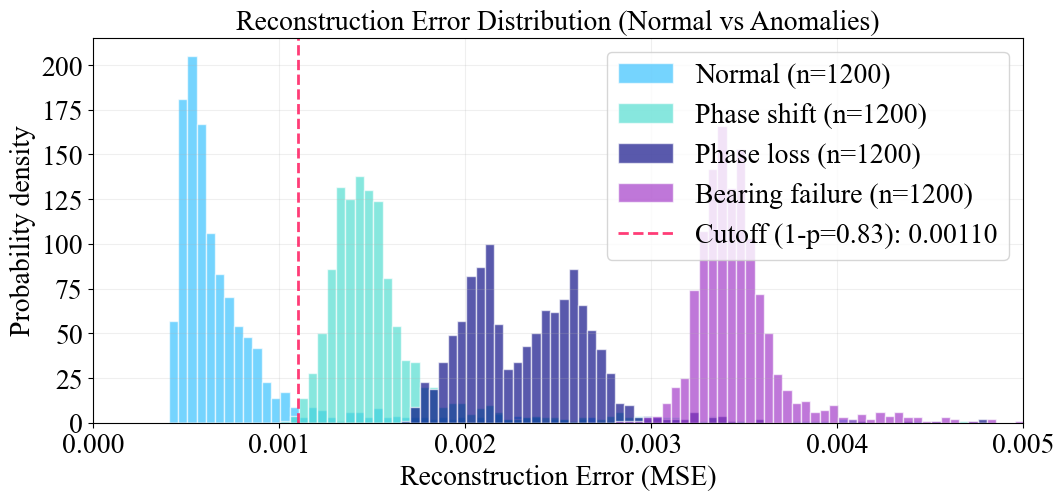

In [11]:
threshold = plot_results(distribution_normal, distribution_phase_shift,
             distribution_phase_loss, distribution_bearing_failure,
             p=0.17, bin_width=0.00005, x_max = 0.005)

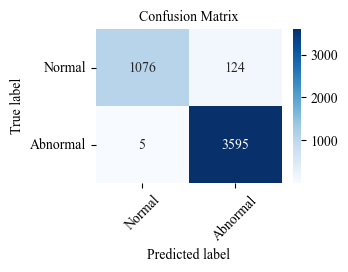

Accuracy: 0.9731
Precision: 0.9667
Recall: 0.9986
F1-score: 0.9824


{'confusion_matrix': array([[1076,  124],
        [   5, 3595]]),
 'accuracy': 0.973125,
 'precision': 0.966657703683786,
 'recall': 0.9986111111111111,
 'f1': 0.982374641344446}

In [12]:
distribution_abnormal = np.concatenate((distribution_bearing_failure, distribution_phase_shift, distribution_phase_loss), axis=0)

confusion_m(distribution_normal, distribution_abnormal, threshold)

In [13]:
import tensorflow as tf
import numpy as np
import shutil
import subprocess
import traceback

# Load the pre-trained Keras model from file.
model = tf.keras.models.load_model('autoendcoder.h5')

# Define the model input specification.
# The model expects a single input sample of dimension 64.
input_shape = (1, 64)
concrete_func = tf.function(model).get_concrete_function(
    tf.TensorSpec(input_shape, tf.float32)
)

# Create a TensorFlow Lite converter from the defined concrete function.
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])

# Define a representative dataset generator for calibration during INT8 quantization.
# This function provides sample inputs that represent the typical range of real data.
def representative_dataset_gen():
    num_samples = min(1000, len(data_train))
    for i in range(num_samples):
        sample = data_train[i].astype(np.float32)
        yield [np.expand_dims(sample, 0)]

# Configure the converter for full integer quantization.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert the model and save it as a TensorFlow Lite file.
model_file = 'autoencoder_normal_seq.tflite'
try:
    print("Starting model conversion...")
    tflite_model_quant = converter.convert()
    print("Model conversion completed successfully.")
    
    with open(model_file, 'wb') as f:
        f.write(tflite_model_quant)
    print(f"TFLite model written to {model_file}")
except Exception:
    print("Error during converter.convert():")
    traceback.print_exc()
    raise

# Generate a C source file (.cc) that embeds the quantized model as a byte array.
# This format allows integration of the model directly into firmware projects.
out_cc = model_file.replace('.tflite', '.cc')
if shutil.which('xxd'):
    # Use the xxd utility if available to create a C array representation.
    subprocess.run(['xxd', '-i', model_file, out_cc], check=True)
    print(f"C source file generated using xxd: {out_cc}")
else:
    # Fallback implementation if xxd is not available.
    data = open(model_file, 'rb').read()
    with open(out_cc, 'w') as f:
        f.write('#include <stdint.h>\n\n')
        array_name = model_file.replace('.', '_').replace('-', '_')
        f.write(f'unsigned char {array_name}[] = {{\n')
        for i in range(0, len(data), 12):
            chunk = data[i:i+12]
            f.write('  ' + ', '.join(str(b) for b in chunk) + ',\n')
        f.write('};\n\n')
        f.write(f'unsigned int {array_name}_len = {len(data)};\n')
    print(f"C source file generated using fallback method: {out_cc}")


Starting model conversion...


2025-10-30 15:51:37.786560: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2025-10-30 15:51:37.786635: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2025-10-30 15:51:37.787215: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-30 15:51:37.787227: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/baotoan/miniconda3/envs/env_tensorflow/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:964: UserWarning: Statistics for quantized inputs were expected, b

Model conversion completed successfully.
TFLite model written to autoencoder_normal_seq.tflite
C source file generated using xxd: autoencoder_normal_seq.cc


In [ ]:
def quantize_array(arr_float, scale, zero_point, dtype):
    """
    Quantize float array to integer dtype using scale & zero_point.
    Clips to dtype range.
    """
    if scale == 0 or np.isnan(scale):
        raise ValueError("Invalid quantization scale (0 or NaN).")
    q = np.round(arr_float / scale + zero_point)
    # clip to dtype range
    if np.issubdtype(dtype, np.integer):
        info = np.iinfo(dtype)
        q = np.clip(q, info.min, info.max)
    return q.astype(dtype)

def dequantize_array(arr_q, scale, zero_point):
    """
    Dequantize integer quantized array back to float32.
    """
    return (arr_q.astype(np.float32) - np.float32(zero_point)) * np.float32(scale)

def inference(tflite_model_path, data):
    """
    Run inference with a fully-quantized INT8 TFLite model and return reconstruction MSEs.
    - tflite_model_path: path to .tflite
    - data: numpy array of original inputs in float32 (shape: [N, 64]).
      Must match the semantic input used during training (normalized data).
    Returns:
      list of reconstruction MSE values computed in float domain, one per 64x64 image.
    """
    # Ensure XNNPACK is disabled
    os.environ["TFLITE_ENABLE_XNNPACK"] = "0"
    
    # load interpreter with XNNPACK disabled for compatibility
    interpreter = tf.lite.Interpreter(
        model_path=tflite_model_path,
        experimental_delegates=None,
        experimental_preserve_all_tensors=False
    )
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_shape = input_details['shape']  # [1, 64]
    in_dtype = input_details['dtype']  # np.int8
    out_dtype = output_details['dtype']

    in_scale, in_zero_point = input_details.get('quantization', (None, None))
    out_scale, out_zero_point = output_details.get('quantization', (None, None))
    print(f"Input quantization: scale={in_scale}, zero_point={in_zero_point}, dtype={in_dtype}")
    print(f"Output quantization: scale={out_scale}, zero_point={out_zero_point}, dtype={out_dtype}")

    if in_scale is None or out_scale is None:
        raise RuntimeError("Model input/output missing quantization parameters.")

    # Ensure input data is float32 for correct quantization formula
    data_float = data.astype(np.float32)
    
    # Check input shape
    if data_float.shape[1] != 64:
        raise ValueError(f"Input data must have shape [N, 64], got {data_float.shape}")

    N = data_float.shape[0]
    reconstruction_errors = []
    
    # Process each 64x64 image (4096 values) in chunks of 64
    for img_idx in tqdm(range(0, N, 64), desc="TFLite inference"):
        if img_idx + 64 > N:  # skip incomplete image
            break
            
        # Get 64 rows for current image
        img_rows = data_float[img_idx:img_idx + 64]
        total_squared_error = 0.0
        
        # Process each row
        for row in img_rows:
            # Prepare input with batch dimension
            input_batch = np.expand_dims(row, axis=0).astype(np.float32)
            
            # Quantize input
            q_input = quantize_array(input_batch, in_scale, in_zero_point, in_dtype)
            
            # Run inference
            interpreter.set_tensor(input_details['index'], q_input)
            interpreter.invoke()
            
            # Get and dequantize output
            q_output = interpreter.get_tensor(output_details['index'])
            output_float = dequantize_array(q_output, out_scale, out_zero_point)
            
            # Accumulate squared error for this row
            squared_error = np.sum(np.square(input_batch - output_float))
            total_squared_error += squared_error
            
        # Calculate MSE for the entire 64x64 image (4096 values)
        image_mse = total_squared_error / 4096  # normalize by total number of pixels
        reconstruction_errors.append(float(image_mse))

    return reconstruction_errors


In [15]:
distribution_normal_q = inference("autoencoder_normal_seq.tflite", data_train)
distribution_bearing_failure_q = inference("autoencoder_normal_seq.tflite", data_bearing_failure)
distribution_phase_shift_q = inference("autoencoder_normal_seq.tflite", data_phase_shift)
distribution_phase_loss_q = inference("autoencoder_normal_seq.tflite", data_phase_loss)

Input quantization: scale=0.0037216455675661564, zero_point=-128, dtype=<class 'numpy.int8'>
Output quantization: scale=0.0036305109970271587, zero_point=-128, dtype=<class 'numpy.int8'>


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
TFLite inference: 100%|██████████| 1200/1200 [00:01<00:00, 1074.14it/s]


Input quantization: scale=0.0037216455675661564, zero_point=-128, dtype=<class 'numpy.int8'>
Output quantization: scale=0.0036305109970271587, zero_point=-128, dtype=<class 'numpy.int8'>


TFLite inference: 100%|██████████| 1200/1200 [00:01<00:00, 1118.72it/s]


Input quantization: scale=0.0037216455675661564, zero_point=-128, dtype=<class 'numpy.int8'>
Output quantization: scale=0.0036305109970271587, zero_point=-128, dtype=<class 'numpy.int8'>


TFLite inference: 100%|██████████| 1200/1200 [00:01<00:00, 1121.17it/s]


Input quantization: scale=0.0037216455675661564, zero_point=-128, dtype=<class 'numpy.int8'>
Output quantization: scale=0.0036305109970271587, zero_point=-128, dtype=<class 'numpy.int8'>


TFLite inference: 100%|██████████| 1200/1200 [00:01<00:00, 1124.42it/s]


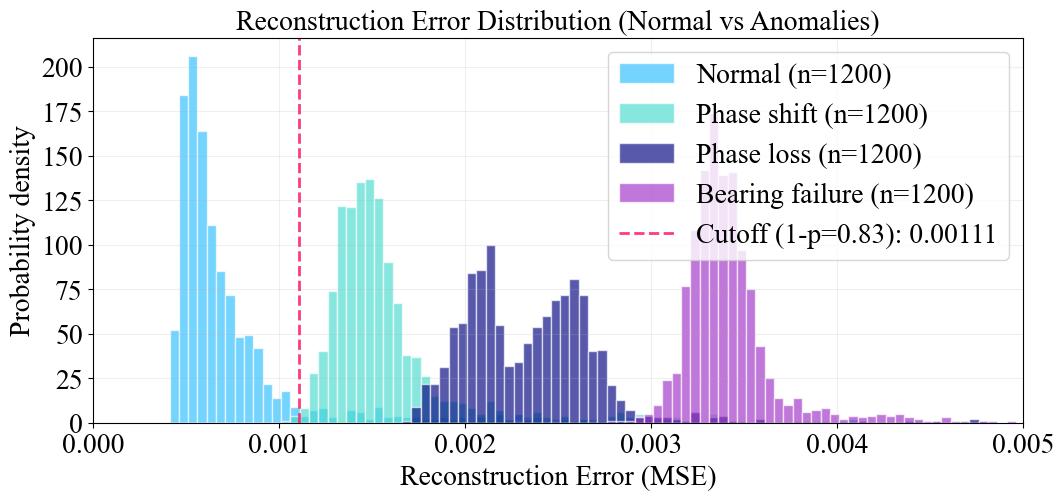

In [16]:
threshold_q = plot_results(distribution_normal_q, distribution_phase_shift_q,
             distribution_phase_loss_q, distribution_bearing_failure_q,
             p=0.17, bin_width=0.00005, x_min=0, x_max=0.005)

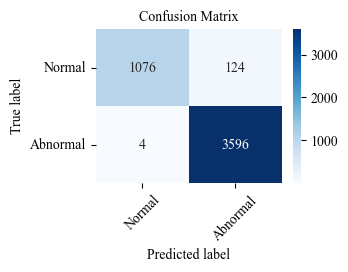

Accuracy: 0.9733
Precision: 0.9667
Recall: 0.9989
F1-score: 0.9825


{'confusion_matrix': array([[1076,  124],
        [   4, 3596]]),
 'accuracy': 0.9733333333333334,
 'precision': 0.9666666666666667,
 'recall': 0.9988888888888889,
 'f1': 0.9825136612021858}

In [17]:
distribution_abnormal_q = np.concatenate((distribution_bearing_failure_q, 
                                          distribution_phase_shift_q, 
                                          distribution_phase_loss_q), axis=0)

confusion_m(distribution_normal_q, distribution_abnormal_q, threshold_q)